# Population geometry of the stimulus response

## tl;dr

For GRB006 session 20240821_121447, signal PC1 explains 31.6% of category-by-response mean activity variance, compared with 6.9% of total single-trial variance. The signal PCA needs 66 components to explain 90% of variance; the single-trial control needs 131. Individual trials are projected into the signal space to show variability around each mean trajectory. Exact stimulus rate is not included.

**Validation status:** executed successfully from top to bottom against the lab database.

## Context & Methods

The analysis uses one recording session at a time because units do not define a shared coordinate system across sessions. The primary signal PCA is fit to six category-by-response mean trajectories. Every individual trial is then projected into that common space. A separate single-trial PCA describes total activity variance. Exact stimulus rate is not included.

### Key assumptions

- Units pass quality criterion 1 and stability parameter 0. No stimulus-response filter is applied.
- Trials have a left or right response, no early withdrawal, and ordered hardware timestamps for first stimulus, center exit, and response-port entry.
- Low-rate, boundary, and high-rate trials are balanced across left and right responses before PCA. Exact rate is not matched.
- Each full trial is normalized into 25 stimulus-to-center-exit bins and 10 center-exit-to-response bins. Bin durations therefore vary across trials and phases.
- Pre-stimulus baseline and unit scaling are estimated from the current balanced trial subset, using 20 ms bins in the 100 ms before first stimulus. High-variance units therefore do not dominate, and scale is not estimated from averaged data.
- PCA uses unsmoothed firing rates. Trajectory figures overlay individual trials, the raw condition mean, and a Gaussian-smoothed mean with a standard deviation of one phase bin. The two task phases are smoothed separately across center exit.
- Phase normalization preserves trajectory shape but not real-time speed.
- The signal and single-trial 90% component counts are descriptive. Random balanced subsampling re-estimates baseline and unit scaling for each draw; it is not a confidence interval. The signal PCA is not evaluated on held-out trials, so it is not yet a cross-validated estimate of signal dimensionality.
- Trajectory comparisons are descriptive. No significance claim is made from visual separation.

## Setup

Load packages and define the visible analysis parameters.

In [1]:
from __future__ import annotations

%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA

from thesis.ephys.trials import build_trial_table
from thesis.ephys.units import fetch_unit_table

warnings.filterwarnings("ignore", category=UserWarning, module="datajoint.plugin")


SUBJECT = "GRB006"
SESSION = "20240821_121447"
UNIT_CRITERIA_ID = 1
STABILITY_PARAM_ID = 0

BASELINE_BINWIDTH_S = 0.020
SMOOTHING_SIGMA_BINS = 1.0
PRE_STIM_S = 0.100
N_STIM_TO_EXIT_BINS = 25
N_EXIT_TO_RESPONSE_BINS = 10
N_RESAMPLES = 100
RANDOM_SEED = 0

CATEGORY_COLORS = {
    "low_rate": "#6A3D9A",
    "boundary": "0.45",
    "high_rate": "#E6AB02",
}
RESPONSE_COLORS = {-1: "#1B9E77", 1: "#D95F02"}

## Data

Load synchronized trials and all units that pass the selected quality and stability filters.

In [2]:
trial_table = build_trial_table(SUBJECT, SESSION, include_frames=False).copy()
unit_table = fetch_unit_table(
    SUBJECT,
    SESSION,
    unit_criteria_id=UNIT_CRITERIA_ID,
    stability_param_id=STABILITY_PARAM_ID,
    include_metrics=False,
)

trial_table["first_stim_s"] = trial_table["stim_pulse_times_s"].str[0]
required_times = ["first_stim_s", "center_exit_s", "response_port_entry_s"]
finite_times = np.isfinite(trial_table[required_times].to_numpy(dtype=float)).all(
    axis=1
)
ordered_events = trial_table["first_stim_s"].lt(
    trial_table["center_exit_s"]
) & trial_table["center_exit_s"].lt(trial_table["response_port_entry_s"])
valid_trials = (
    trial_table["response"].isin((-1, 1))
    & trial_table["early_withdrawal"].fillna(1).eq(0)
    & trial_table["stim_category"].notna()
    & finite_times
    & ordered_events
)
eligible_trials = trial_table.loc[valid_trials].reset_index(drop=True)

if eligible_trials.empty:
    raise RuntimeError("No trials pass the PCA inclusion rules.")

print(f"Session: {SUBJECT} {SESSION}")
print(f"Units: {len(unit_table)}")
print(f"Eligible trials: {len(eligible_trials)} / {len(trial_table)}")
display(
    eligible_trials.groupby(["stim_category", "response"], observed=True)
    .size()
    .rename("trials")
    .unstack(fill_value=0)
)

[2026-09-03 13:44:36,364][INFO]: DataJoint 0.14.8 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


/Users/gabriel/lib/thesis-pca-analysis/src/thesis/ephys/trials.py:107: RuntimeWarning: No measured obx/io1 for GRB006 20240821_121447; using synchronized Bpod sound-command times
  sess_ev, stim_pulses = fetch_session_events(


Session: GRB006 20240821_121447
Units: 168
Eligible trials: 294 / 504


response,-1,1
stim_category,,
low_rate,105,25
boundary,36,17
high_rate,64,47


Balance stimulus category and response so common trial types do not dominate the PCA basis.

In [3]:
def sample_balanced_indices(trials, rng, *, replace):
    groups = [
        group.index.to_numpy(dtype=int)
        for _, group in trials.groupby(
            ["stim_category", "response"], observed=True, sort=True
        )
    ]
    if len(groups) != 6:
        raise RuntimeError(
            "Expected low, boundary, and high categories with both responses."
        )
    n_per_group = min(map(len, groups))
    if n_per_group < 2:
        raise RuntimeError(
            f"The least represented category-by-response group has {n_per_group} trial(s)."
        )
    return np.sort(
        np.concatenate(
            [rng.choice(group, n_per_group, replace=replace) for group in groups]
        )
    )


rng = np.random.default_rng(RANDOM_SEED)
balanced_trial_indices = sample_balanced_indices(eligible_trials, rng, replace=False)
balanced_trials = eligible_trials.iloc[balanced_trial_indices]

print(f"Balanced PCA trials: {len(balanced_trials)}")
display(
    balanced_trials.groupby(["stim_category", "response"], observed=True)
    .size()
    .rename("trials")
    .unstack(fill_value=0)
)

Balanced PCA trials: 102


response,-1,1
stim_category,,
low_rate,17,17
boundary,17,17
high_rate,17,17


Convert spikes into unsmoothed firing rates for phase-normalized trajectories and the pre-stimulus baseline.

In [4]:
spike_times_by_unit = [
    np.sort(np.asarray(spike_times, dtype=float))
    for spike_times in unit_table["spike_times_s"]
]
unit_ids = unit_table["unit_id"].to_numpy(dtype=int)
n_pre_stim_bins = round(PRE_STIM_S / BASELINE_BINWIDTH_S)


def firing_rates_in_bins(edges_s):
    bin_durations_s = np.diff(edges_s)
    return np.column_stack(
        [
            np.diff(np.searchsorted(spike_times_s, edges_s)) / bin_durations_s
            for spike_times_s in spike_times_by_unit
        ]
    )


def phase_rates(trial):
    stim_to_exit_edges = np.linspace(
        trial["first_stim_s"],
        trial["center_exit_s"],
        N_STIM_TO_EXIT_BINS + 1,
    )
    exit_to_response_edges = np.linspace(
        trial["center_exit_s"],
        trial["response_port_entry_s"],
        N_EXIT_TO_RESPONSE_BINS + 1,
    )
    return np.vstack(
        [
            firing_rates_in_bins(stim_to_exit_edges),
            firing_rates_in_bins(exit_to_response_edges),
        ]
    )


phase_activity = np.stack(
    [phase_rates(trial) for _, trial in eligible_trials.iterrows()]
)
baseline_activity = np.stack(
    [
        firing_rates_in_bins(
            np.linspace(
                trial["first_stim_s"] - PRE_STIM_S,
                trial["first_stim_s"],
                n_pre_stim_bins + 1,
            )
        )
        for _, trial in eligible_trials.iterrows()
    ]
)

print("Phase activity:", phase_activity.shape, "(trials, phase bins, units)")
print("Baseline activity:", baseline_activity.shape)

Phase activity: (294, 35, 168) (trials, phase bins, units)
Baseline activity: (294, 5, 168)


## Results

Fit the primary PCA to category-by-response mean trajectories. Fit a separate single-trial PCA as a control, then project every trial through the signal basis.

In [5]:
SIGNAL_CONDITIONS = [
    (category, response)
    for category in ("low_rate", "boundary", "high_rate")
    for response in (-1, 1)
]


def standardize_population_activity(activity, baseline, reference_indices):
    baseline_rate = baseline[reference_indices].mean(axis=(0, 1))
    reference_activity = activity[reference_indices] - baseline_rate
    unit_scale = reference_activity.reshape(-1, activity.shape[-1]).std(axis=0, ddof=1)
    included_units = np.isfinite(unit_scale) & (unit_scale > 0)
    standardized = (
        activity[..., included_units] - baseline_rate[included_units]
    ) / unit_scale[included_units]
    return standardized, included_units


def condition_mean_activity(activity, trials, trial_indices):
    selected_trials = trials.iloc[trial_indices]
    categories = selected_trials["stim_category"].astype(str).to_numpy()
    responses = selected_trials["response"].to_numpy(dtype=int)
    selected_activity = activity[trial_indices]
    return np.stack(
        [
            selected_activity[(categories == category) & (responses == response)].mean(
                axis=0
            )
            for category, response in SIGNAL_CONDITIONS
        ]
    )


def fit_population_pca(activity):
    model = PCA(svd_solver="covariance_eigh").fit(
        activity.reshape(-1, activity.shape[-1])
    )
    cumulative_variance = np.cumsum(model.explained_variance_ratio_)
    n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)
    return model, n_components_90


def project_activity(activity, model):
    original_shape = activity.shape[:-1]
    scores = model.transform(activity.reshape(-1, activity.shape[-1])).reshape(
        *original_shape, -1
    )
    baseline_score = model.transform(np.zeros((1, activity.shape[-1])))[0]
    return scores - baseline_score


standardized_phase_activity, included_units = standardize_population_activity(
    phase_activity,
    baseline_activity,
    balanced_trial_indices,
)
signal_condition_activity = condition_mean_activity(
    standardized_phase_activity,
    eligible_trials,
    balanced_trial_indices,
)

signal_pca, signal_n_components_90 = fit_population_pca(signal_condition_activity)
single_trial_pca, single_trial_n_components_90 = fit_population_pca(
    standardized_phase_activity[balanced_trial_indices]
)
signal_phase_scores = project_activity(standardized_phase_activity, signal_pca)

print(f"Units retained after variance check: {included_units.sum()} / {len(unit_ids)}")
print(
    "Signal PCA variance explained by PC1-3:",
    np.round(100 * signal_pca.explained_variance_ratio_[:3], 2),
)
print(f"Signal PCA components explaining at least 90%: {signal_n_components_90}")
print(
    "Single-trial PCA variance explained by PC1-3:",
    np.round(100 * single_trial_pca.explained_variance_ratio_[:3], 2),
)
print(
    "Single-trial PCA components explaining at least 90%:",
    single_trial_n_components_90,
)

Units retained after variance check: 168 / 168
Signal PCA variance explained by PC1-3: [31.6   7.05  5.76]
Signal PCA components explaining at least 90%: 66
Single-trial PCA variance explained by PC1-3: [6.91 2.12 1.84]
Single-trial PCA components explaining at least 90%: 131


Repeat balanced sampling without replacement, re-estimating baseline and unit scaling each time, to measure how sensitive both 90% component counts are to trial selection.

In [6]:
resample_rng = np.random.default_rng(RANDOM_SEED + 1)
resampled_signal_n_components_90 = np.empty(N_RESAMPLES, dtype=int)
resampled_single_trial_n_components_90 = np.empty(N_RESAMPLES, dtype=int)

for resample in range(N_RESAMPLES):
    resampled_indices = sample_balanced_indices(
        eligible_trials, resample_rng, replace=False
    )
    resampled_activity, _ = standardize_population_activity(
        phase_activity,
        baseline_activity,
        resampled_indices,
    )
    resampled_signal_activity = condition_mean_activity(
        resampled_activity,
        eligible_trials,
        resampled_indices,
    )
    _, resampled_signal_n_components_90[resample] = fit_population_pca(
        resampled_signal_activity
    )
    _, resampled_single_trial_n_components_90[resample] = fit_population_pca(
        resampled_activity[resampled_indices]
    )

signal_resampling_interval = np.percentile(
    resampled_signal_n_components_90, [2.5, 97.5]
)
single_trial_resampling_interval = np.percentile(
    resampled_single_trial_n_components_90, [2.5, 97.5]
)
print(
    f"Signal PCA n90 = {signal_n_components_90}; "
    f"balanced-resampling 95% range = "
    f"[{signal_resampling_interval[0]:.0f}, {signal_resampling_interval[1]:.0f}]"
)
print(
    f"Single-trial PCA n90 = {single_trial_n_components_90}; "
    f"balanced-resampling 95% range = "
    f"[{single_trial_resampling_interval[0]:.0f}, "
    f"{single_trial_resampling_interval[1]:.0f}]"
)

Signal PCA n90 = 66; balanced-resampling 95% range = [64, 67]
Single-trial PCA n90 = 131; balanced-resampling 95% range = [130, 131]


Compare cumulative explained variance for task-related condition means and total single-trial activity.

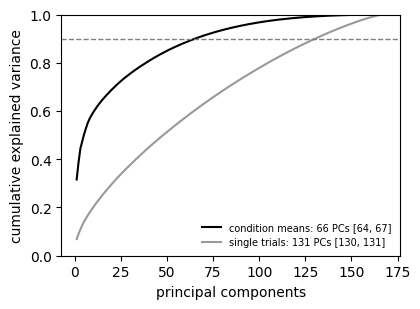

In [7]:
signal_cumulative_variance = np.cumsum(signal_pca.explained_variance_ratio_)
single_trial_cumulative_variance = np.cumsum(single_trial_pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(
    np.arange(1, len(signal_cumulative_variance) + 1),
    signal_cumulative_variance,
    color="black",
    label=(
        f"condition means: {signal_n_components_90} PCs "
        f"[{signal_resampling_interval[0]:.0f}, {signal_resampling_interval[1]:.0f}]"
    ),
)
ax.plot(
    np.arange(1, len(single_trial_cumulative_variance) + 1),
    single_trial_cumulative_variance,
    color="0.6",
    label=(
        f"single trials: {single_trial_n_components_90} PCs "
        f"[{single_trial_resampling_interval[0]:.0f}, "
        f"{single_trial_resampling_interval[1]:.0f}]"
    ),
)
ax.axhline(0.90, color="0.5", linestyle="--", linewidth=1)
ax.set(
    xlabel="principal components",
    ylabel="cumulative explained variance",
    ylim=(0, 1),
)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()

Prepare balanced condition groups. Exact rates are retained only when both responses have at least five trials.

In [8]:
balanced_categories = (
    eligible_trials.iloc[balanced_trial_indices]["stim_category"].astype(str).to_numpy()
)
balanced_responses = eligible_trials.iloc[balanced_trial_indices]["response"].to_numpy(
    dtype=int
)
category_groups = {
    category: balanced_trial_indices[balanced_categories == category]
    for category in ("low_rate", "boundary", "high_rate")
}
response_groups = {
    response: balanced_trial_indices[balanced_responses == response]
    for response in (-1, 1)
}

Plot phase-normalized trajectories in the signal PC1-PC2 space. Thin paths show individual trials, faint lines show raw condition means, and strong lines show Gaussian-smoothed means. Markers show task events, and arrows show the direction of time.

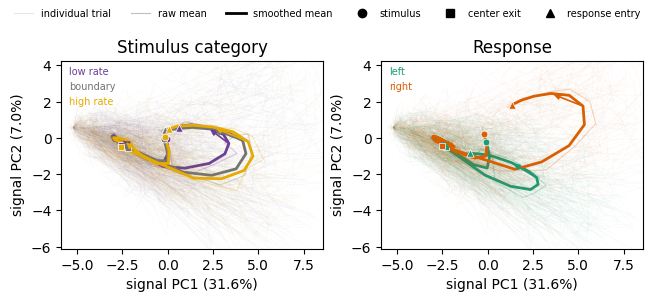

In [9]:
phase_group_specs = [
    (
        "Stimulus category",
        [
            (category.replace("_", " "), indices, CATEGORY_COLORS[category])
            for category, indices in category_groups.items()
        ],
    ),
    (
        "Response",
        [
            ("left" if response == -1 else "right", indices, RESPONSE_COLORS[response])
            for response, indices in response_groups.items()
        ],
    ),
]


def add_time_arrow(ax, scores, index, color):
    ax.annotate(
        "",
        xy=scores[index + 1, :2],
        xytext=scores[index - 1, :2],
        arrowprops={
            "arrowstyle": "-|>",
            "color": color,
            "linewidth": 1.2,
            "mutation_scale": 8,
        },
    )


def add_group_key(ax, groups):
    for row, (label, _, color) in enumerate(groups):
        ax.text(
            0.03,
            0.97 - 0.08 * row,
            label,
            color=color,
            fontsize=7,
            transform=ax.transAxes,
            va="top",
        )


def plot_phase_groups(ax, groups):
    means = []
    for _, indices, color in groups:
        for trial_scores in signal_phase_scores[indices, :, :2]:
            ax.plot(
                trial_scores[:, 0],
                trial_scores[:, 1],
                color=color,
                linewidth=0.4,
                alpha=0.04,
            )

        mean_scores = signal_phase_scores[indices, :, :2].mean(axis=0)
        smoothed_scores = np.vstack(
            [
                gaussian_filter1d(
                    mean_scores[:N_STIM_TO_EXIT_BINS],
                    SMOOTHING_SIGMA_BINS,
                    axis=0,
                    mode="nearest",
                ),
                gaussian_filter1d(
                    mean_scores[N_STIM_TO_EXIT_BINS:],
                    SMOOTHING_SIGMA_BINS,
                    axis=0,
                    mode="nearest",
                ),
            ]
        )
        means.append(mean_scores)
        ax.plot(
            mean_scores[:, 0],
            mean_scores[:, 1],
            color=color,
            linewidth=0.8,
            alpha=0.25,
        )
        ax.plot(
            smoothed_scores[:, 0],
            smoothed_scores[:, 1],
            color=color,
            linewidth=2,
        )
        ax.scatter(
            *smoothed_scores[0],
            color=color,
            marker="o",
            s=24,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        ax.scatter(
            *smoothed_scores[N_STIM_TO_EXIT_BINS - 1],
            color=color,
            marker="s",
            s=24,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        ax.scatter(
            *smoothed_scores[-1],
            color=color,
            marker="^",
            s=28,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        add_time_arrow(ax, smoothed_scores, N_STIM_TO_EXIT_BINS // 2, color)
        add_time_arrow(
            ax,
            smoothed_scores,
            N_STIM_TO_EXIT_BINS + N_EXIT_TO_RESPONSE_BINS // 2,
            color,
        )

    add_group_key(ax, groups)
    ax.set_xlabel(f"signal PC1 ({100 * signal_pca.explained_variance_ratio_[0]:.1f}%)")
    ax.set_ylabel(f"signal PC2 ({100 * signal_pca.explained_variance_ratio_[1]:.1f}%)")
    ax.set_aspect("equal", adjustable="box")
    return means


fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.0), layout="constrained")
all_means = []
for ax, (title, groups) in zip(axes, phase_group_specs, strict=True):
    all_means.extend(plot_phase_groups(ax, groups))
    ax.set_title(title)

combined_means = np.concatenate(all_means, axis=0)
trial_score_bounds = np.percentile(
    signal_phase_scores[:, :, :2].reshape(-1, 2),
    [1, 99],
    axis=0,
)
lower_bounds = np.minimum(trial_score_bounds[0], combined_means.min(axis=0))
upper_bounds = np.maximum(trial_score_bounds[1], combined_means.max(axis=0))
padding = max(
    1e-6, 0.05 * np.ptp(np.vstack([lower_bounds, upper_bounds]), axis=0).max()
)
for ax in axes:
    ax.set_xlim(lower_bounds[0] - padding, upper_bounds[0] + padding)
    ax.set_ylim(lower_bounds[1] - padding, upper_bounds[1] + padding)

event_handles = [
    Line2D([], [], color="0.5", linewidth=0.5, alpha=0.3, label="individual trial"),
    Line2D([], [], color="black", linewidth=0.8, alpha=0.25, label="raw mean"),
    Line2D([], [], color="black", linewidth=2, label="smoothed mean"),
    Line2D([], [], color="black", marker="o", linestyle="none", label="stimulus"),
    Line2D([], [], color="black", marker="s", linestyle="none", label="center exit"),
    Line2D([], [], color="black", marker="^", linestyle="none", label="response entry"),
]
fig.legend(
    handles=event_handles,
    frameon=False,
    fontsize=7,
    ncols=6,
    loc="upper center",
);

## Takeaways

- Signal PC1-3 explain 31.6%, 7.1%, and 5.8% of condition-mean variance, respectively.
- The signal PCA needs 66 components to explain 90% of variance. Repeated balanced trial selections give a central 95% range of 64-67 components.
- The single-trial control needs 131 components to explain 90% of total activity variance, compared with a central resampling range of 130-131. This small mismatch shows some sensitivity to the selected trials.
- Mean response trajectories show the clearest visible separation late in the trial. Category trajectories overlap more strongly.
- Individual trajectories remain widely distributed around the condition means.

These results are descriptive. Visible trajectory separation does not establish statistical separation or show that category and response occupy independent neural dimensions. The signal dimensionality is not yet cross-validated. Exact-rate geometry is left for a later analysis with rate-specific matching.